# Análisis Exploratorio de Datos (EDA)

Vamos a responder a las siguientes preguntas:
- ¿Cuántos datos (columnas y filas) tenemos?
- ¿Cuáles son las estadísticas descriptivas de cada columna?
- ¿Tenemos datos faltantes?
- ¿Cuáles son las correlaciones entre las variables?
- Graficar la distribución de las variables numéricas.

In [8]:
import pandas as pd

raw_data = pd.read_csv("data.csv")
raw_data

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [9]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


### Observaciones
1. No hay varaibles categóricas
2. La columna 'No' es una columna índice
3. La columna X1 maneja fechas, las cuales estan en un formato que se conoce como Año Decimal (o Decimal Year). El número antes del punto representa el año (2012), y la parte decimal (0.917) representa la fracción de tiempo transcurrido de ese año. Por ejemplo, 2012.917 equivale aproximadamente a noviembre de 2012.
4. No hay tipo de datos a cambiar en las demas columnas, se mantienen bajo sus mismos valores

In [20]:
# No hay aplicación de One Hot Encoding

# Columna índice
clean_data = pd.DataFrame(index=raw_data['No'])

# Manejo de fechas
años = raw_data["X1 transaction date"].astype(int) # Esto nos da el año entero
fracciones = raw_data["X1 transaction date"] - años # Esto nos da la fracción
fecha_base = pd.to_datetime(años, format="%Y") # Esto nos da 1 de Enero de ese año
# Calculamos los días que representa la fracción (asumiendo 365.25 por bisiestos)
dias_totales = fracciones * 365.25
delta_tiempo = pd.to_timedelta(dias_totales, unit="D")
# Sumamos ambos para tener la fecha exacta
clean_data["Date"] = (fecha_base + delta_tiempo).dt.normalize().values # Usamos normalize en lugar de date para mantener el tipo de dato datetime

# No hubo cambios en las siguientes columnas...
columnas_sin_cambios = ['X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'Y house price of unit area']

nuevos_nombres = [
    "house_age",
    "distance_to_mrt",
    "convenience_stores",
    "latitude",
    "longitude",
    "house_price",
]

clean_data[nuevos_nombres] = raw_data[columnas_sin_cambios].values
print(clean_data)
clean_data.info()

          Date  house_age  distance_to_mrt  convenience_stores  latitude  \
No                                                                         
1   2012-11-30       32.0         84.87882                10.0  24.98298   
2   2012-11-30       19.5        306.59470                 9.0  24.98034   
3   2013-08-01       13.3        561.98450                 5.0  24.98746   
4   2013-07-02       13.3        561.98450                 5.0  24.98746   
5   2012-10-31        5.0        390.56840                 5.0  24.97937   
..         ...        ...              ...                 ...       ...   
410 2013-01-01       13.7       4082.01500                 0.0  24.94155   
411 2012-08-31        5.6         90.45606                 9.0  24.97433   
412 2013-04-02       18.8        390.96960                 7.0  24.97923   
413 2013-01-01        8.1        104.81010                 5.0  24.96674   
414 2013-07-02        6.5         90.45606                 9.0  24.97433   

     longit

In [22]:
print("Dimensión de la tabla: %s renglones( datos), %s columnas (variables)" % df.shape) 

# Estadísticas descriptivas
estadisticas = clean_data.describe()
print("Estadísticas descriptivas\n", estadisticas)

Dimensión de la tabla: 414 renglones( datos), 9 columnas (variables)
Estadísticas descriptivas
                                 Date   house_age  distance_to_mrt  \
count                            414  414.000000       414.000000   
mean   2013-02-23 15:25:13.043478272   17.712560      1083.885689   
min              2012-08-31 00:00:00    0.000000        23.382840   
25%              2012-11-30 00:00:00    9.025000       289.324800   
50%              2013-03-02 00:00:00   16.100000       492.231300   
75%              2013-06-02 00:00:00   28.150000      1454.279000   
max              2013-08-01 00:00:00   43.800000      6488.021000   
std                              NaN   11.392485      1262.109595   

       convenience_stores    latitude   longitude  house_price  
count          414.000000  414.000000  414.000000   414.000000  
mean             4.094203   24.969030  121.533361    37.980193  
min              0.000000   24.932070  121.473530     7.600000  
25%              1.000

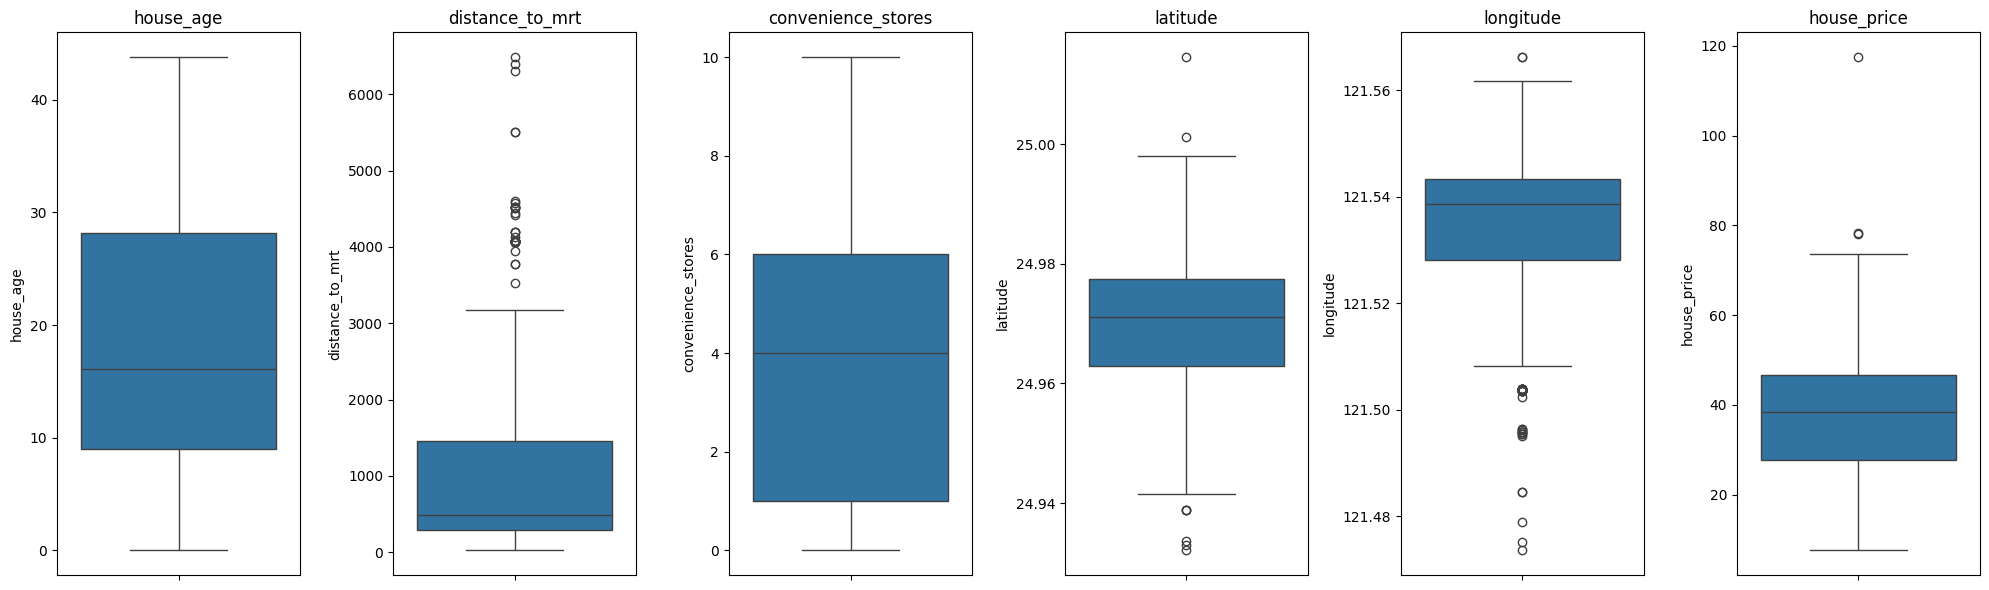

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos el DataFrame para quedarnos solo con las columnas flotantes
df_floats = clean_data.select_dtypes(include=["float"])
columnas_floats = df_floats.columns

# 2. Ajustamos la cuadrícula (subplots) al número exacto de columnas flotantes detectadas
# Si sabes que siempre son un número fijo, puedes dejar ncols estático.
fig, axs = plt.subplots(ncols=len(columnas_floats), nrows=1, figsize=(20, 6))

# Nos aseguramos de que axs sea un arreglo plano (útil si hay 1 o más gráficas)
if len(columnas_floats) > 1:
    axs = axs.flatten()
else:
    axs = [axs]

# 3. Graficamos usando el DataFrame filtrado
for i, col in enumerate(columnas_floats):
    sns.boxplot(y=df_floats[col], ax=axs[i])
    axs[i].set_title(col)  # Agrega el nombre de la columna como título para identificarla

plt.tight_layout()  # Evita que se encimen los textos
plt.show()

In [28]:
clean_data.corr(numeric_only=True).abs()


,house_age,distance_to_mrt,convenience_stores,latitude,longitude,house_price
house_age,1.000000,0.025622,0.049593,0.054420,0.048520,0.210567
distance_to_mrt,0.025622,1.000000,0.602519,0.591067,0.806317,0.673613
convenience_stores,0.049593,0.602519,1.000000,0.444143,0.449099,0.571005
latitude,0.054420,0.591067,0.444143,1.000000,0.412924,0.546307
longitude,0.048520,0.806317,0.449099,0.412924,1.000000,0.523287
house_price,0.210567,0.673613,0.571005,0.546307,0.523287,1.000000


In [ ]:
import ... 
X = df["distance_to_mrt"].values
Y = df["house_price"].values

modelo = mdr.RegresionLinealSimple(X,Y)
modelo.plot_with_intervals()

ModuleNotFoundError: No module named 'mdr'

In [ ]:
modelo.summary()